# TedX — corpus-level results

Automated corpus results for the English TED corpus. Everything here is **collection
level**: one number per corpus, built from all its videos, not per talk.

Sections map onto the specification:

| here | spec | note |
|---|---|---|
| 3 | §2 Most frequent words | normalised per 1,000 tokens, with dispersion |
| 4 | §5 Wrist velocity | body-normalised, replacing the pixel metric |
| 5 | §4 Pitch level and variation | speaker-relative, in semitones |
| 6 | §3 Shots and angles | within-corpus percentages |

**Deliberately elsewhere.** Keyness (§2's EN–ZH comparison step), the shot
chi-square (§3) and the EN–ZH concept mapping (§7.3) belong to the
comparative notebook — they are two-corpus statistics and cannot be computed
here. Cross-modal correlation (§6) is in `04_multimodal_coupling.ipynb`,
which treats it as a question about timescale rather than a single matrix.

In [1]:
import sys, warnings
from pathlib import Path

sys.path.insert(0, str(Path.cwd() if Path.cwd().name == "notebooks" else Path.cwd() / "notebooks"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import _corpus as C

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)
plt.rcParams.update({
    "figure.figsize": (11, 3.2), "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 9,
})

MODALITY_COLOUR = {"gesture": "#C84B31", "prosody": "#2D6A4F",
                   "verbal": "#1B4F8A", "camera": "#7B5EA7"}

CORPUS = "TedX"

print("corpora present in MongoDB:", C.available_corpora())

corpora present in MongoDB: ['TedX', 'Yixi']


## 1. Does this corpus have data?

In [2]:
# One download for every section below: videos, windows (with the pitch and
# normalised-gesture columns already merged in) and the per-video wordlists.
# Cached on disk under $WORK_DIR/corpus_cache and keyed by the corpus' job ids
# and window counts, so adding, reprocessing or deleting a video invalidates it
# automatically. refresh=True forces a re-fetch; offline=True trusts the cache
# without contacting MongoDB, for working through an Atlas outage.
data = C.load_corpus(CORPUS)

videos = data.videos
df = data.windows
HAS_DATA = not df.empty and not videos.empty

print(data)
print(f"\n{len(df)} windows across {df.job_id.nunique() if HAS_DATA else 0} videos"
      f"  |  {videos.duration_s.sum()/60:.0f} min of footage" if HAS_DATA else "no data")

# Same talk shipped twice under different job ids would double-count every
# statistic below. load_videos catches one job on two shards; this catches two
# jobs holding the same talk, which a re-ship with a changed drive_url can do.
if HAS_DATA:
    dupes = videos[videos.duplicated("label", keep=False)].sort_values("label")
    if not dupes.empty:
        print("\nWARNING — duplicate labels (same talk stored twice?):")
        print(dupes[["job_id", "label", "total_windows"]].to_string(index=False))

/home/abx13/Prog/Mannerism-Analyzer/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
loading TedX: 4/4 |██████████| , gesture  

cached to /home/abx13/.local/share/mannerism/corpus_cache/TedX_94fcfd3229ddfc2f.pkl
<CorpusData TedX: 39 videos, 6013 windows, 5576 with normalised gesture, 21958 per-video word rows>

6013 windows across 39 videos  |  499 min of footage


## 2. Coverage — how much of each measurement exists

Read this before any number below. A confident-looking mean over 12% of
windows is not a corpus result.

Gesture rows are missing wherever the pipeline found no pose — scenes showing
the audience, the slides, or a shot too wide to track. Those windows are NaN,
not zero, so they are excluded rather than averaged in as "held perfectly
still".

In [3]:
if not HAS_DATA:
    print("skipped — no data")
else:
    display(C.coverage_report(df).head(20))
    print(f"pose present in {df.pose_present_ratio.gt(0).mean():.0%} of windows; "
          f"mean coverage within those: {df.loc[df.pose_present_ratio>0,'pose_present_ratio'].mean():.2f}")

,non_null,total,coverage
wrist_speed_p90,5576,6013,0.927
wrist_speed_max,5576,6013,0.927
n_samples,5576,6013,0.927
wrist_speed_mean,5576,6013,0.927
max_wrist_displacement,5661,6013,0.941
handedness_ratio,5661,6013,0.941
mean_wrist_velocity,5661,6013,0.941
vertical_angle,5661,6013,0.941
horizontal_angle,5661,6013,0.941
mean_face_pitch_deg,5661,6013,0.941


pose present in 94% of windows; mean coverage within those: 0.92


## 3. Most frequent words  — spec §2

Counts are normalised two ways, because "frequency per 1,000 tokens" is
ambiguous between them and they answer different questions:

* **`freq_per_1000`** — pooled over the corpus. Every *token* weighs the same,
  so a 27-minute talk contributes more than a 6-minute one.
* **`mean_video_freq`** — each video's own rate, averaged. Every *speaker*
  weighs the same.

Where they disagree, one talk is driving the word. `n_videos` and `range_pct`
(document frequency) make that explicit: a word appearing 200 times in one
talk and nowhere else is a property of that speaker, not of TedX.

Rows are per (word, part-of-speech) by default, so *to*-the-infinitive and
*to*-the-preposition stay separate; `by_pos=False` merges them.

In [4]:
if not HAS_DATA:
    print("skipped — no data")
else:
    wl = data.wordlist()
    print(f"{len(wl)} (word, POS) types over {wl.attrs['corpus_tokens']:,.0f} tokens "
          f"from {wl.attrs['n_videos']} videos")
    display(wl.head(25)[["word", "pos", "count", "freq_per_1000",
                         "mean_video_freq", "n_videos", "range_pct"]].round(2))

7482 (word, POS) types over 66,956 tokens from 39 videos


,word,pos,count,freq_per_1000,mean_video_freq,n_videos,range_pct
0,the,DET,2479,37.02,37.25,39,100.00
1,and,CCONJ,2294,34.26,34.42,39,100.00
2,to,PART,1715,25.61,33.72,30,76.92
3,i,PRON,1625,24.27,23.60,39,100.00
4,a,DET,1524,22.76,22.76,39,100.00
5,of,ADP,1423,21.25,22.34,38,97.44
6,in,ADP,1152,17.21,17.61,39,100.00
7,we,PRON,925,13.82,13.83,39,100.00
8,it,PRON,862,12.87,12.91,38,97.44
9,you,PRON,745,11.13,10.58,39,100.00


### Content words

Function words dominate any raw frequency list and say little about subject
matter. Restricting to content parts of speech is the usual first cut; it is a
display choice, not a statistical one, so the unfiltered list above stays
available.

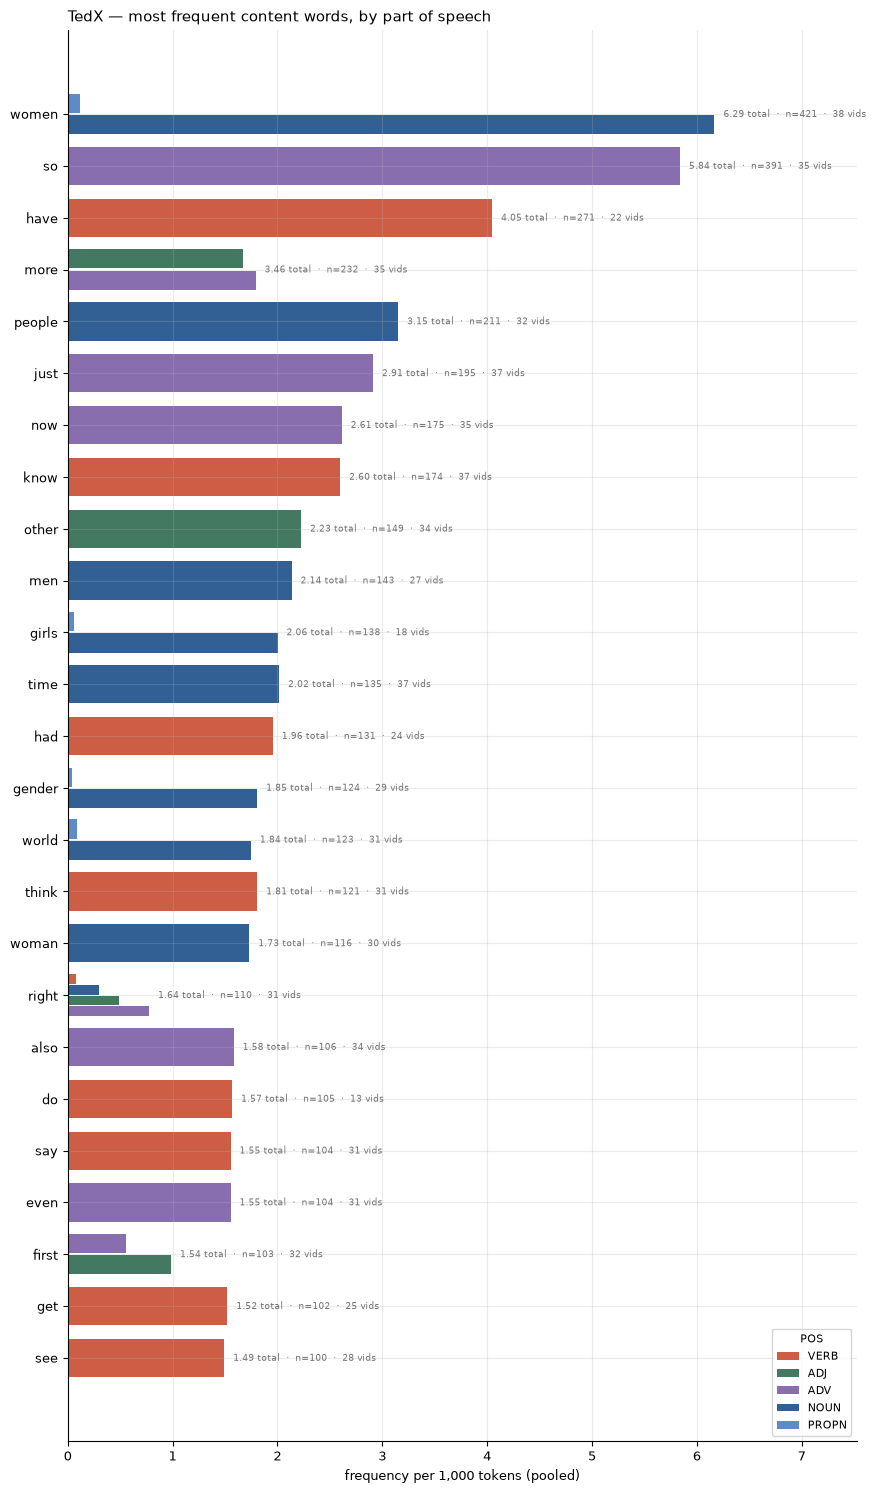

content words appearing under more than one part of speech:


,word,pos,count,freq_per_1000,n_videos
50,first,ADJ,66,0.99,18
116,first,ADV,37,0.55,14
13,gender,NOUN,121,1.81,28
2149,gender,PROPN,3,0.04,1
10,girls,NOUN,134,2.00,17
1507,girls,PROPN,4,0.06,1
14,more,ADV,120,1.79,17
17,more,ADJ,112,1.67,18
73,right,ADV,52,0.78,12
142,right,ADJ,33,0.49,12


,word,count,freq_per_1000,mean_video_freq,n_videos,range_pct
0,women,421,6.29,7.21,38,97.44
1,so,391,5.84,6.65,35,89.74
2,have,271,4.05,7.11,22,56.41
3,more,232,3.46,4.00,35,89.74
4,people,211,3.15,4.20,32,82.05
5,just,195,2.91,3.02,37,94.87
6,now,175,2.61,2.79,35,89.74
7,know,174,2.60,2.82,37,94.87
8,other,149,2.23,2.68,34,87.18
9,men,143,2.14,3.22,27,69.23


In [14]:
CONTENT_POS = ["NOUN", "PROPN", "VERB", "ADJ", "ADV"]
POS_COLOUR = {"NOUN": "#1B4F8A", "PROPN": "#4A7FC1", "VERB": "#C84B31",
              "ADJ": "#2D6A4F", "ADV": "#7B5EA7"}

if HAS_DATA:
    content = data.wordlist(pos=CONTENT_POS)                 # split by POS
    merged = data.wordlist(pos=CONTENT_POS, by_pos=False)    # one row per word

    # Ranked by the word's total frequency, but drawn as one bar per part of
    # speech, side by side within the word's slot. Only the tags a word
    # actually has are drawn, so a single-role word keeps a full-height bar
    # instead of sitting beside four empty ones.
    top_words = merged.head(25).word.tolist()
    per_word = {w: g.sort_values("count", ascending=False)
                for w, g in content[content.word.isin(top_words)].groupby("word")}

    SLOT = 0.82
    fig, ax = plt.subplots(figsize=(9, 15))
    drawn = set()
    for i, word in enumerate(top_words[::-1]):          # bottom-up
        rows = per_word.get(word)
        if rows is None:
            continue
        n = len(rows)
        h = SLOT / n
        for j, (_, r) in enumerate(rows.iterrows()):
            y = i - SLOT / 2 + (j + 0.5) * h
            ax.barh(y, r.freq_per_1000, height=h * 0.9,
                    color=POS_COLOUR.get(r.pos, "0.5"), alpha=0.9,
                    label=r.pos if r.pos not in drawn else None)
            drawn.add(r.pos)
            # if n > 1:                                   # name the split inline
            #     ax.text(r.freq_per_1000, y, f" {r.pos}", va="center",
            #             fontsize=6, color="0.3")

    ax.set_yticks(range(len(top_words)), top_words[::-1])
    ax.set_xlabel("frequency per 1,000 tokens (pooled)")
    ax.set_title(f"{CORPUS} — most frequent content words, by part of speech",
                 loc="left")
    ax.legend(title="POS", fontsize=8, title_fontsize=8, loc="lower right")

    # Totals sit past the word's longest bar, on the word's own row — drawn
    # above the slot they overlapped the neighbouring word's bars.
    totals = merged.set_index("word").reindex(top_words)
    for i, word in enumerate(top_words[::-1]):
        r = totals.loc[word]
        widest = per_word[word].freq_per_1000.max() if word in per_word else 0.0
        ax.text(widest, i, f"   {r.freq_per_1000:.2f} total"
                f"  ·  n={int(r['count'])}  ·  {int(r.n_videos)} vids",
                fontsize=6.5, color="0.45", va="center")
    ax.margins(x=0.22)
    plt.tight_layout(); plt.show()

    multi = (content[content.word.isin(top_words)]
             .groupby("word").filter(lambda g: len(g) > 1)
             .sort_values(["word", "count"], ascending=[True, False]))
    if not multi.empty:
        print("content words appearing under more than one part of speech:")
        display(multi[["word", "pos", "count", "freq_per_1000", "n_videos"]].round(2))

    display(merged.head(25)[["word", "count", "freq_per_1000", "mean_video_freq",
                             "n_videos", "range_pct"]].round(2))

### Dispersion — corpus word or one speaker's word?

Each point is a content word: how often it occurs against how many videos
carry it. Words low and to the left of the mass are frequent *because of one
talk*. Anything used for a corpus-level claim should sit high on the vertical
axis.

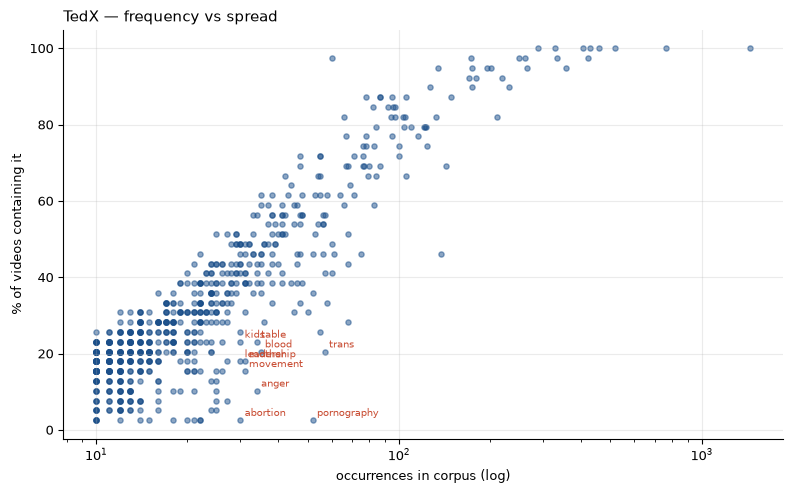

frequent but concentrated in few videos — treat as speaker-specific:


,word,count,n_videos,range_pct
141,trans,57,8,20.512821
159,pornography,52,1,2.564103
221,blood,35,8,20.512821
233,table,34,9,23.076923
237,anger,34,4,10.256410
247,mother,31,7,17.948718
253,movement,31,6,15.384615
260,abortion,30,1,2.564103
269,leadership,30,7,17.948718
270,kids,30,9,23.076923


In [16]:
if HAS_DATA:
    # Merged across parts of speech on purpose. Rows split by POS report the
    # dispersion of a *grammatical role*, not of a word: "to" is PART in 31
    # videos and ADP in 9, but the word itself is in all 39, and spaCy tagging
    # "is" as VERB in 2 talks and AUX in 37 would otherwise mark it as
    # speaker-specific vocabulary.
    flat = data.wordlist(by_pos=False)
    content_words = set(data.wordlist(pos=CONTENT_POS).word)
    sub = flat[(flat["count"] >= 10) & (flat.word.isin(content_words))]

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(sub["count"], sub.range_pct, s=14, alpha=0.5,
               color=MODALITY_COLOUR["verbal"])
    ax.set_xscale("log")
    ax.set_xlabel("occurrences in corpus (log)"); ax.set_ylabel("% of videos containing it")
    ax.set_title(f"{CORPUS} — frequency vs spread", loc="left")

    narrow = sub[(sub.range_pct < 25) & (sub["count"] >= 30)].head(12)
    for _, r in narrow.iterrows():
        ax.annotate(r.word, (r["count"], r.range_pct), fontsize=7,
                    xytext=(3, 3), textcoords="offset points", color="#C84B31")
    plt.tight_layout(); plt.show()

    if not narrow.empty:
        print("frequent but concentrated in few videos — treat as speaker-specific:")
        display(narrow[["word", "count", "n_videos", "range_pct"]])

## 4. Gesture magnitude, body-normalised  — spec §5

The stored `mean_wrist_velocity` is **pixels per second**, which confounds
gesture size with shot scale (a close-up makes the same movement sweep more
pixels) and with video resolution. §5 asks for normalisation "relative to body
scale in frame", which is what `load_corpus` computes (via
`wrist_speed_series`): wrist
displacement divided by the speaker's own shoulder width and torso height, per
axis, from the dense pose keyframes. Units are **shoulder-widths per second**.

Per-axis matters: `pose_x` is normalised by frame width and `pose_y` by frame
height, so on 16:9 footage vertical distances are inflated ~1.78× before any
body scaling.

No reprocessing is needed — the keyframes were already stored.

In [17]:
if not HAS_DATA:
    print("skipped — no data")
else:
    gest = data.gesture
    dfg = df                      # load_corpus already merged the gesture columns
    print(f"{len(gest)} windows with a normalised gesture measure "
          f"({gest.job_id.nunique()} videos)")
    display(gest[["wrist_speed_mean", "wrist_speed_p90", "wrist_speed_max"]]
            .describe().T[["count", "mean", "50%", "75%", "max"]].round(2))

5576 windows with a normalised gesture measure (39 videos)


,count,mean,50%,75%,max
wrist_speed_mean,5576.0,1.27,1.08,1.66,19.30
wrist_speed_p90,5576.0,2.30,1.76,2.94,47.45
wrist_speed_max,5576.0,11.06,5.52,12.46,169.71


### Does the normalisation actually remove the framing confound?

The test that matters, not an assumption: correlate each gesture metric with
`mean_face_bbox_area`, which is a direct proxy for how close the shot is. The
pixel metric should correlate with it; the body-normalised one should not.

,metric,rho vs shot scale,n
0,pixels/s (stored),0.469,5635
1,shoulder-widths/s (normalised),0.322,5558
2,"shoulder-widths/s, 90th pct",0.343,5558


closer to 0 = less contaminated by how close the camera is


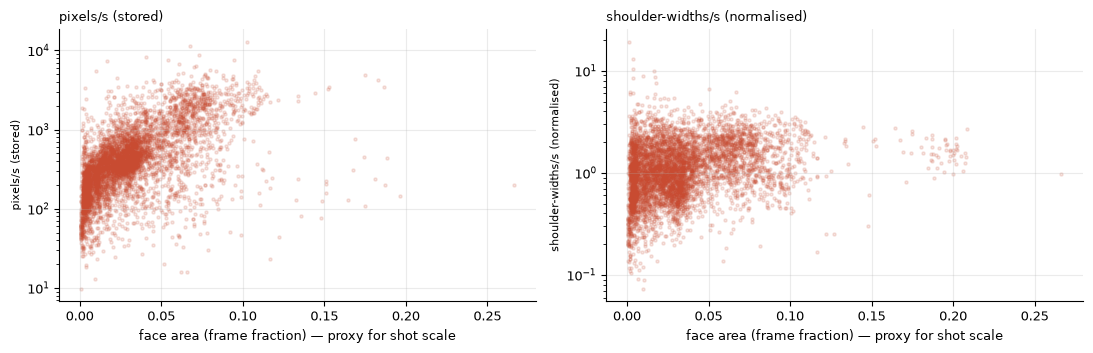

In [18]:
from scipy.stats import spearmanr

if HAS_DATA:
    checks = [("mean_wrist_velocity", "pixels/s (stored)"),
              ("wrist_speed_mean", "shoulder-widths/s (normalised)"),
              ("wrist_speed_p90", "shoulder-widths/s, 90th pct")]
    rows = []
    for col, label in checks:
        sub = dfg[[col, "mean_face_bbox_area"]].dropna()
        if len(sub) > 30:
            rho = spearmanr(sub[col], sub.mean_face_bbox_area).statistic
            rows.append({"metric": label, "rho vs shot scale": round(rho, 3), "n": len(sub)})
    conf = pd.DataFrame(rows)
    display(conf)
    print("closer to 0 = less contaminated by how close the camera is")

    fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
    for ax, (col, label) in zip(axes, checks[:2]):
        sub = dfg[[col, "mean_face_bbox_area"]].dropna()
        ax.scatter(sub.mean_face_bbox_area, sub[col], s=5, alpha=0.15,
                   color=MODALITY_COLOUR["gesture"])
        ax.set_yscale("log")
        ax.set_xlabel("face area (frame fraction) — proxy for shot scale")
        ax.set_ylabel(label, fontsize=8)
        ax.set_title(label, loc="left", fontsize=9)
    plt.tight_layout(); plt.show()

### Per-speaker gesture magnitude

§5 also asks for per-speaker normalisation for "individual differences in
movement amplitude". Shown rather than applied: the spread *between* speakers
is itself a result, and averaging it away would hide it. Divide by each
speaker's median if a later analysis needs within-speaker variation only.

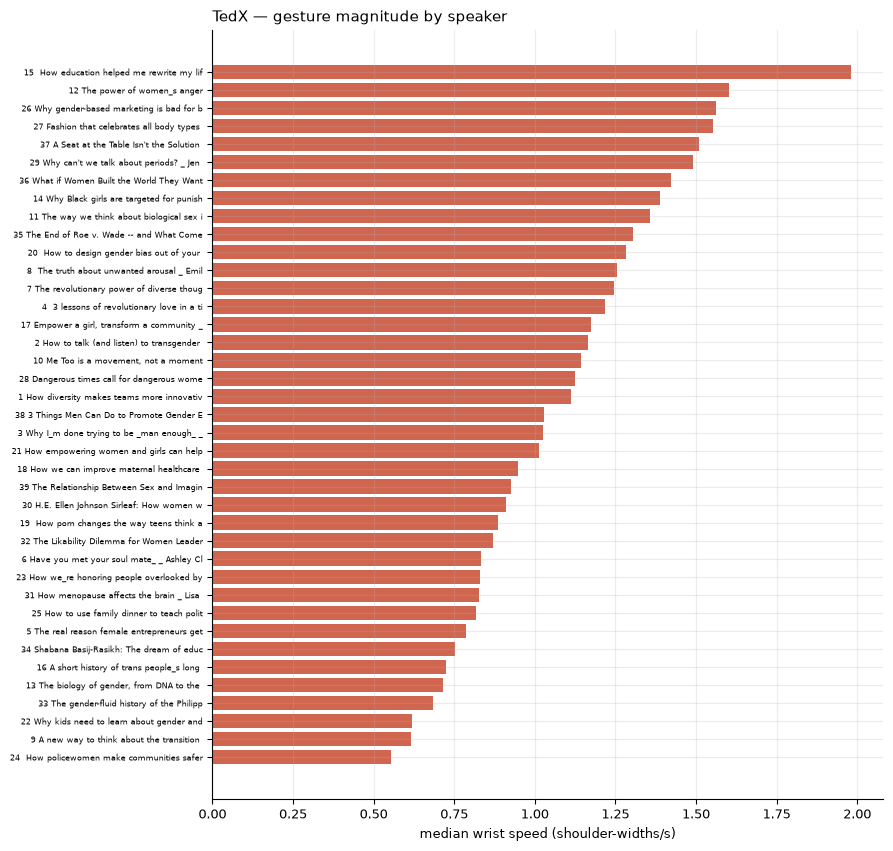

largest speaker median is 3.6x the smallest — individual differences remain after body normalisation


In [19]:
if HAS_DATA:
    by_video = (gest.groupby("job_id").wrist_speed_mean
                .agg(["median", "count"]).reset_index()
                .merge(videos[["job_id", "label"]], on="job_id", how="left")
                .sort_values("median"))
    by_video["label"] = by_video.label.fillna(by_video.job_id).str.slice(0, 42)

    fig, ax = plt.subplots(figsize=(9, max(3, 0.22 * len(by_video))))
    ax.barh(by_video.label, by_video["median"], color=MODALITY_COLOUR["gesture"], alpha=0.85)
    ax.set_xlabel("median wrist speed (shoulder-widths/s)")
    ax.set_title(f"{CORPUS} — gesture magnitude by speaker", loc="left")
    ax.tick_params(axis="y", labelsize=6)
    plt.tight_layout(); plt.show()

    spread = by_video["median"].max() / max(by_video["median"].min(), 1e-9)
    print(f"largest speaker median is {spread:.1f}x the smallest — "
          f"individual differences remain after body normalisation")

## 5. Pitch level and variation  — spec §4

Both measures are **relative to each speaker's own baseline**, as §4 requires:
an absolute Hz threshold would mostly sort speakers by voice type rather than
by discourse style.

* `pitch_st` — the window's mean f0 in **semitones** from that speaker's
  median. Semitones rather than z-scores because pitch is perceived
  logarithmically, so "+3 st" is the same perceptual step for any voice,
  whereas "+1 SD" depends on how variable that speaker happens to be.
* `pitch_level` / `pitch_variation` — **tertiles within each speaker**, so
  "high" means high *for them*.

The working assumption to test downstream: low + stable = authoritative /
assertive, high + variable = emotional / engaging.

**Caveat for the ZH corpus** (recorded here so it is not forgotten in the
comparison): Mandarin is tonal, so much of its f0 movement is lexical tone
rather than discourse style. `pitch_variation` is therefore not directly
comparable across the two corpora.

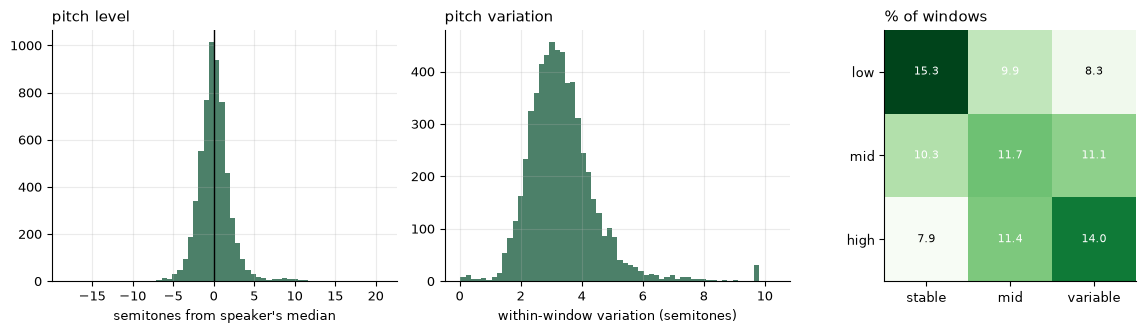

pitch in semitones from own median: median +0.00, 10th-90th [-2.10, +2.23]

the two assumption corners (spec §4):
    low + stable      911 windows (15.3%)   <- authoritative / assertive
   high + variable    832 windows (14.0%)   <- emotional / engaging


In [21]:
if not HAS_DATA:
    print("skipped — no data")
else:
    dfp = dfg                 # pitch columns added by load_corpus
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))

    axes[0].hist(dfp.pitch_st.dropna(), bins=60, color=MODALITY_COLOUR["prosody"], alpha=0.85)
    axes[0].set_xlabel("semitones from speaker's median"); axes[0].set_title("pitch level", loc="left")
    axes[0].axvline(0, color="k", lw=1)

    axes[1].hist(dfp.pitch_var_st.dropna(), bins=60, color=MODALITY_COLOUR["prosody"], alpha=0.85)
    axes[1].set_xlabel("within-window variation (semitones)"); axes[1].set_title("pitch variation", loc="left")

    cross = (pd.crosstab(dfp.pitch_level, dfp.pitch_variation, normalize=True) * 100)
    cross = cross.reindex(index=["low", "mid", "high"], columns=["stable", "mid", "variable"])
    im = axes[2].imshow(cross.values, cmap="Greens")
    axes[2].set_xticks(range(3), cross.columns); axes[2].set_yticks(range(3), cross.index)
    axes[2].set_title("% of windows", loc="left"); axes[2].grid(False)
    for i in range(3):
        for j in range(3):
            v = cross.values[i, j]
            axes[2].text(j, i, f"{v:.1f}", ha="center", va="center",
                         color="white" if v > cross.values.max() * 0.6 else "black", fontsize=8)
    plt.tight_layout(); plt.show()

    print("pitch in semitones from own median: "
          f"median {dfp.pitch_st.median():+.2f}, "
          f"10th-90th [{dfp.pitch_st.quantile(.1):+.2f}, {dfp.pitch_st.quantile(.9):+.2f}]")
    print("\nthe two assumption corners (spec §4):")
    tot = len(dfp.dropna(subset=["pitch_level", "pitch_variation"]))
    for lvl, var, reading in [("low", "stable", "authoritative / assertive"),
                              ("high", "variable", "emotional / engaging")]:
        n = int(((dfp.pitch_level == lvl) & (dfp.pitch_variation == var)).sum())
        print(f"   {lvl:>4} + {var:<9} {n:>5} windows ({n/tot:.1%})   <- {reading}")

### Speaker baselines

The absolute medians the relative measure is built on. Wide spread here is
exactly why §4 insists on speaker-relative measures — and note that in a mixed
corpus this axis largely reflects voice type, not style.

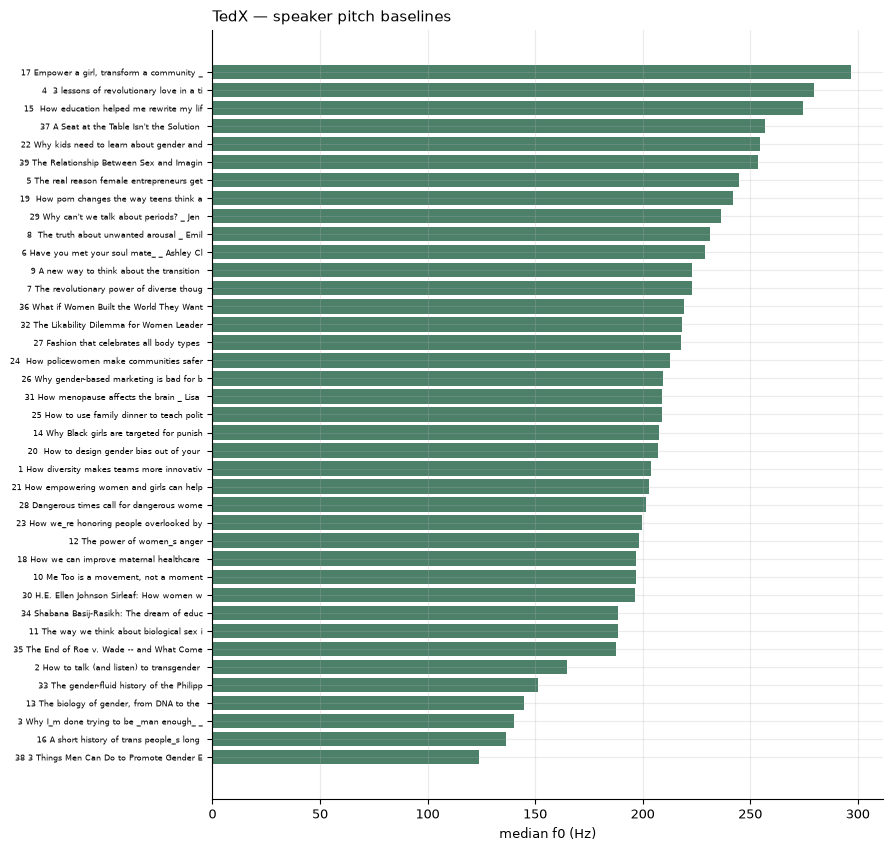

baselines span 124-297 Hz


In [ ]:
if HAS_DATA:
    base = (dfp.groupby("job_id").mean_f0.median().reset_index()
            .merge(videos[["job_id", "label"]], on="job_id", how="left")
            .sort_values("mean_f0"))
    base["label"] = base.label.fillna(base.job_id).str.slice(0, 42)
    fig, ax = plt.subplots(figsize=(9, max(3, 0.22 * len(base))))
    ax.barh(base.label, base.mean_f0, color=MODALITY_COLOUR["prosody"], alpha=0.85)
    ax.set_xlabel("median f0 (Hz)"); ax.set_title(f"{CORPUS} — speaker pitch baselines", loc="left")
    ax.tick_params(axis="y", labelsize=6)
    plt.tight_layout(); plt.show()
    print(f"baselines span {base.mean_f0.min():.0f}-{base.mean_f0.max():.0f} Hz")

## 6. Shots and angles  — spec §3

Within-corpus distribution as percentages of classified windows. Two things to
keep in mind:

* These are **per-window dominant** labels, not per-shot-segment labels, so a
  window straddling a cut is attributed to whichever shot dominates it.
* Editing is a production choice. Differences between corpora here may say
  more about the broadcaster than about the speaker.

Shots-per-minute normalisation and the EN–ZH chi-square are two-corpus
statistics and live in the comparative notebook.

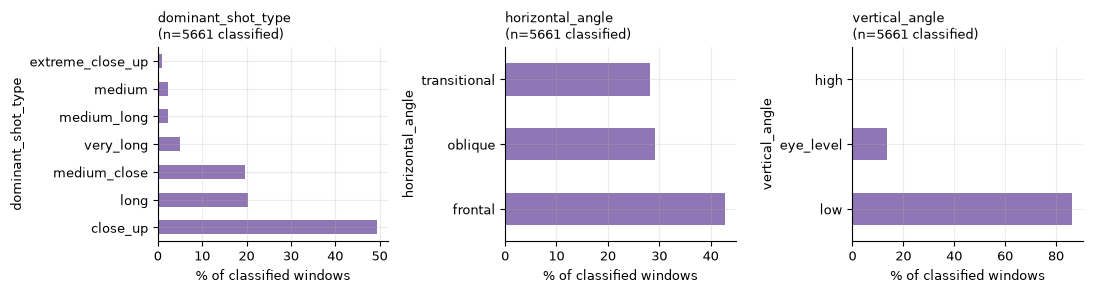


dominant_shot_type:
   close_up                 2802  (47% of all windows)
   long                     1146  (19% of all windows)
   medium_close             1114  (19% of all windows)
   MISSING (unclassified)    352  (6% of all windows)
   very_long                 289  (5% of all windows)
   medium_long               129  (2% of all windows)
   medium                    127  (2% of all windows)
   extreme_close_up           54  (1% of all windows)

horizontal_angle:
   frontal                  2419  (40% of all windows)
   oblique                  1650  (27% of all windows)
   transitional             1592  (26% of all windows)
   MISSING (unclassified)    352  (6% of all windows)

vertical_angle:
   low                      4886  (81% of all windows)
   eye_level                 769  (13% of all windows)
   MISSING (unclassified)    352  (6% of all windows)
   high                        6  (0% of all windows)

cuts per minute: median 5.6, range 3.6-9.6


In [20]:
if not HAS_DATA:
    print("skipped — no data")
else:
    cats = [c for c in ["dominant_shot_type", "horizontal_angle", "vertical_angle"] if c in df.columns]
    fig, axes = plt.subplots(1, len(cats), figsize=(11, 3))
    axes = np.atleast_1d(axes)
    for ax, col in zip(axes, cats):
        vc = df[col].value_counts(dropna=True)
        if vc.empty:
            ax.text(0.5, 0.5, "no classified windows", ha="center", va="center"); ax.axis("off"); continue
        (vc / vc.sum() * 100).plot.barh(ax=ax, color=MODALITY_COLOUR["camera"], alpha=0.85)
        ax.set_title(f"{col}\n(n={int(vc.sum())} classified)", fontsize=9, loc="left")
        ax.set_xlabel("% of classified windows")
    plt.tight_layout(); plt.show()

    for col in cats:
        vc = df[col].value_counts(dropna=False)
        print(f"\n{col}:")
        for k, n in vc.items():
            k = "MISSING (unclassified)" if pd.isna(k) else k
            print(f"   {str(k):<24} {n:>4}  ({n/len(df):.0%} of all windows)")

    cuts = df.groupby("job_id").cut_count.sum()
    mins = videos.set_index("job_id").duration_s / 60
    cpm = (cuts / mins).dropna()
    print(f"\ncuts per minute: median {cpm.median():.1f}, range {cpm.min():.1f}-{cpm.max():.1f}")

## 7. Temporal trends — how a talk evolves

Per-window metrics against position in the talk (0 = start, 1 = end), averaged
across videos so talks of different lengths can be overlaid. Gesture uses the
**normalised** metric.

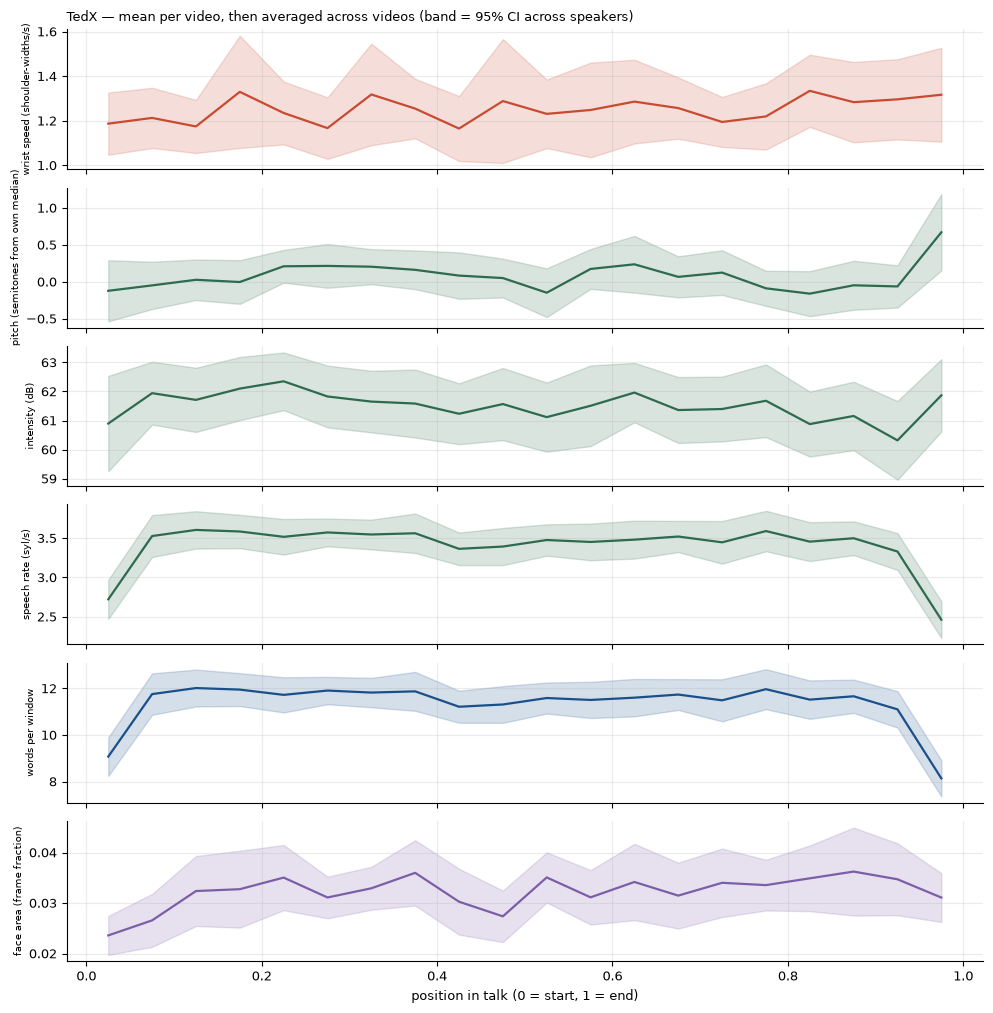

In [23]:
if not HAS_DATA:
    print("skipped — no data")
else:
    metrics = [
        ("wrist_speed_mean",      "gesture", "wrist speed (shoulder-widths/s)"),
        ("pitch_st",              "prosody", "pitch (semitones from own median)"),
        ("mean_intensity_db",     "prosody", "intensity (dB)"),
        ("speech_rate_syl_per_s", "prosody", "speech rate (syl/s)"),
        ("word_count",            "verbal",  "words per window"),
        ("mean_face_bbox_area",   "camera",  "face area (frame fraction)"),
    ]
    metrics = [m for m in metrics if m[0] in dfp.columns and dfp[m[0]].notna().any()]

    bins = np.linspace(0, 1, 21)
    dfp["progress_bin"] = pd.cut(dfp.progress, bins, labels=(bins[:-1] + 0.025))

    fig, axes = plt.subplots(len(metrics), 1, figsize=(10, 1.7 * len(metrics)), sharex=True)
    axes = np.atleast_1d(axes)
    for ax, (col, mod, label) in zip(axes, metrics):
        per_video = dfp.groupby(["job_id", "progress_bin"], observed=True)[col].mean()
        curve = per_video.groupby("progress_bin", observed=True).agg(["mean", "sem"])
        x = curve.index.astype(float)
        ax.plot(x, curve["mean"], color=MODALITY_COLOUR[mod], lw=1.6)
        ax.fill_between(x, curve["mean"] - 1.96 * curve["sem"],
                        curve["mean"] + 1.96 * curve["sem"],
                        color=MODALITY_COLOUR[mod], alpha=0.18)
        ax.set_ylabel(label, fontsize=7)
    axes[-1].set_xlabel("position in talk (0 = start, 1 = end)")
    axes[0].set_title(f"{CORPUS} — mean per video, then averaged across videos "
                      f"(band = 95% CI across speakers)", loc="left", fontsize=9)
    plt.tight_layout(); plt.show()

## 8. Summary table

One row per measure, in the units this notebook standardises on. This is the
table to quote from; the pixel-based gesture metric is deliberately absent.

In [24]:
if HAS_DATA:
    summary = []
    spec = [
        ("gesture", "wrist speed (shoulder-widths/s)", "wrist_speed_mean"),
        ("gesture", "pose coverage (ratio)",           "pose_present_ratio"),
        ("prosody", "pitch (semitones from median)",   "pitch_st"),
        ("prosody", "pitch variation (semitones)",     "pitch_var_st"),
        ("prosody", "intensity (dB)",                  "mean_intensity_db"),
        ("prosody", "speech rate (syl/s)",             "speech_rate_syl_per_s"),
        ("verbal",  "words per window",                "word_count"),
        ("camera",  "cuts per window",                 "cut_count"),
        ("camera",  "face area (frame fraction)",      "mean_face_bbox_area"),
    ]
    for mod, label, col in spec:
        if col not in dfp.columns:
            continue
        s = dfp[col].dropna()
        if s.empty:
            continue
        summary.append({"modality": mod, "measure": label, "n windows": len(s),
                        "median": round(s.median(), 3),
                        "IQR": f"{s.quantile(.25):.2f}–{s.quantile(.75):.2f}",
                        "% of all windows": f"{len(s)/len(dfp):.0%}"})
    display(pd.DataFrame(summary))

,modality,measure,n windows,median,IQR,% of all windows
0,gesture,wrist speed (shoulder-widths/s),5576,1.076,0.70–1.66,93%
1,gesture,pose coverage (ratio),6013,1.000,0.98–1.00,100%
2,prosody,pitch (semitones from median),5946,0.000,-1.07–1.05,99%
3,prosody,pitch variation (semitones),5946,3.219,2.64–3.86,99%
4,prosody,intensity (dB),6011,62.469,58.13–65.92,100%
5,prosody,speech rate (syl/s),6011,3.300,2.70–4.20,100%
6,verbal,words per window,6013,11.000,9.00–14.00,100%
7,camera,cuts per window,6013,0.000,0.00–1.00,100%
8,camera,face area (frame fraction),5869,0.026,0.01–0.04,98%


## 9. Reading these results

* **Always read a number against its coverage.** Gesture measures exist only
  where a pose was tracked; the "% of all windows" column in section 8 is the
  honest denominator.
* **Gesture is in body units now.** Any earlier figure in pixels is not
  comparable with these, and section 4's confound check is the evidence for
  preferring them.
* **Pitch is speaker-relative by construction**, so `pitch_st` cannot be
  compared against another corpus' raw Hz — only against another
  speaker-relative measure.
* **Word frequencies need their dispersion.** Quote `n_videos` alongside any
  count; §7.2's principle — never a percentage without its n — applies here
  just as much as in the search bar.
* **Nothing here is a comparison.** Keyness, the shot chi-square and the
  concept mapping are two-corpus statistics; cross-modal correlation is in
  notebook 04.